# Importing necessary libraries

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import seaborn as sns
from collections import defaultdict
import random
import matplotlib.image as mpimg

## For this project i am working on UTKFace Dataset. To build a model that can predict **Age** and **Gender**.

# EDA

In [48]:
images = glob.glob("/kaggle/input/datasets/jangedoo/utkface-new/UTKFace/*")
age_data = {}
gender_data = {}
data_map = defaultdict(list)
for image in images:
    image_splited = image.split("_")
    
    age = int(image_splited[0].split("/")[-1])
    gender = int(image_splited[1])

    age_data[age] = age_data.get(age,0)+1
    gender_data[gender] = gender_data.get(gender,0)+1

    data_map[f'{age}_{gender}'].append(image)
    
age_data = dict(sorted(age_data.items() , key=lambda item: int(item[0])))

In [49]:
print(f"Total number of avaible samples: {len(images)}")

Total number of avaible samples: 23708


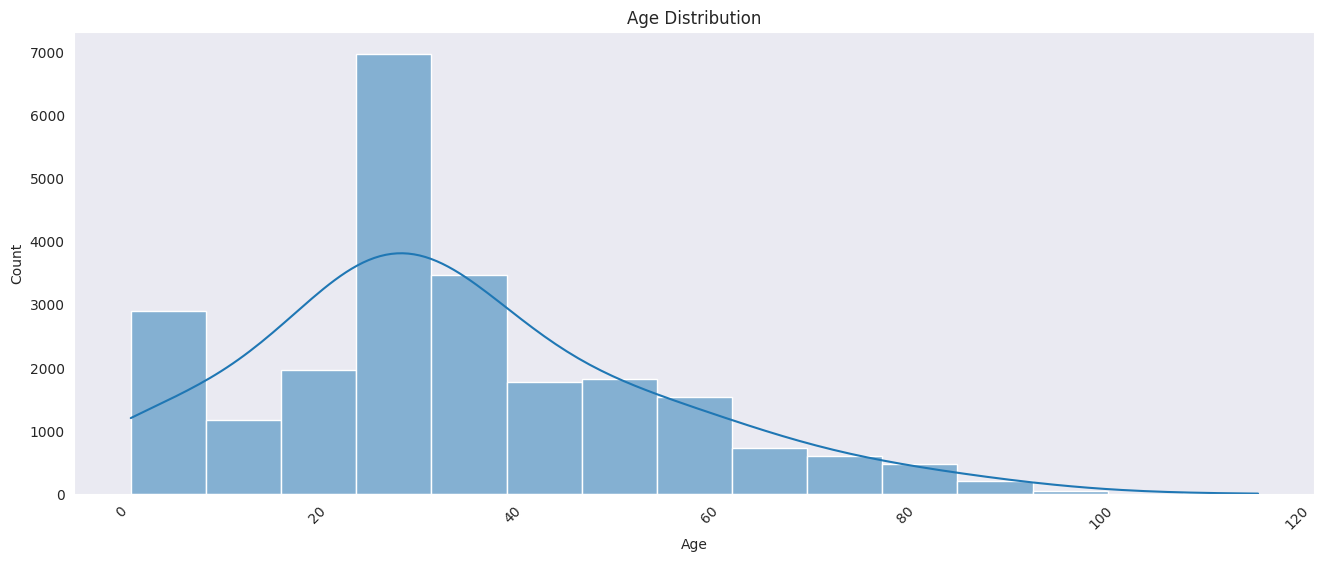

In [50]:
sns.set_style("dark")
plt.figure(figsize=(16,6))
sns.histplot(x=list(age_data.keys()), weights=list(age_data.values()), kde=True, bins=15)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.xticks(rotation=45)
plt.show()

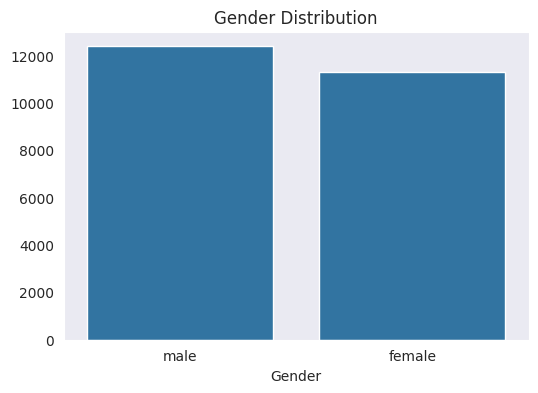

In [51]:
sns.set_style("dark")
plt.figure(figsize=(6,4))
sns.barplot(x=["male","female"], y=list(gender_data.values()), legend=[{1:"female"},{0:"Male"}])
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.show()

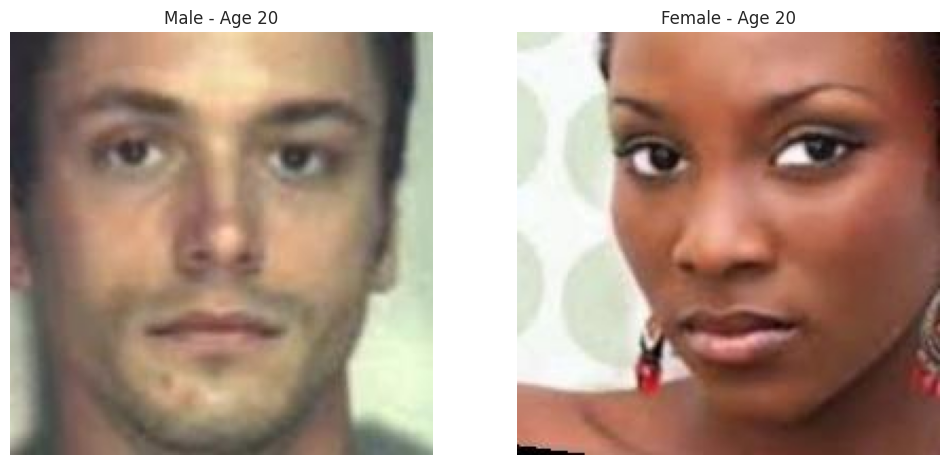

In [76]:
male_age_20 = data_map["20_0"][0]
m20_image = mpimg.imread(male_age_20)

female_age_20 = data_map["20_1"][0]
f20_image = mpimg.imread(female_age_20)

fig, axes = plt.subplots(1,2, figsize=(12,6))
axes[0].imshow(m20_image)
axes[0].axis('off') 
axes[0].set_title("Male - Age 20")

axes[1].imshow(f20_image)
axes[1].axis('off')
axes[1].set_title("Female - Age 20")
plt.show()

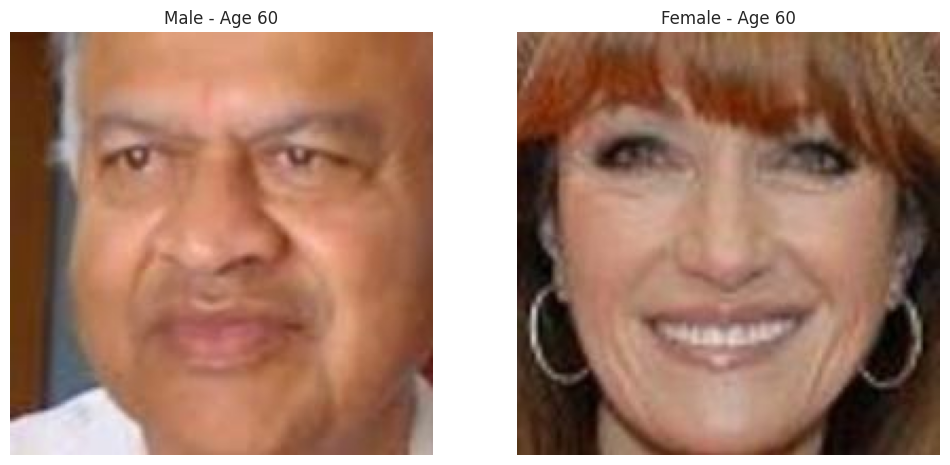

In [77]:
male_age_60 = data_map["60_0"][0]
m60_image = mpimg.imread(male_age_60)

female_age_60 = data_map["60_1"][0]
f60_image = mpimg.imread(female_age_60)

fig, axes = plt.subplots(1,2, figsize=(12,6))
axes[0].imshow(m60_image)
axes[0].axis('off') 
axes[0].set_title("Male - Age 60")

axes[1].imshow(f60_image)
axes[1].axis('off')
axes[1].set_title("Female - Age 60")
plt.show()

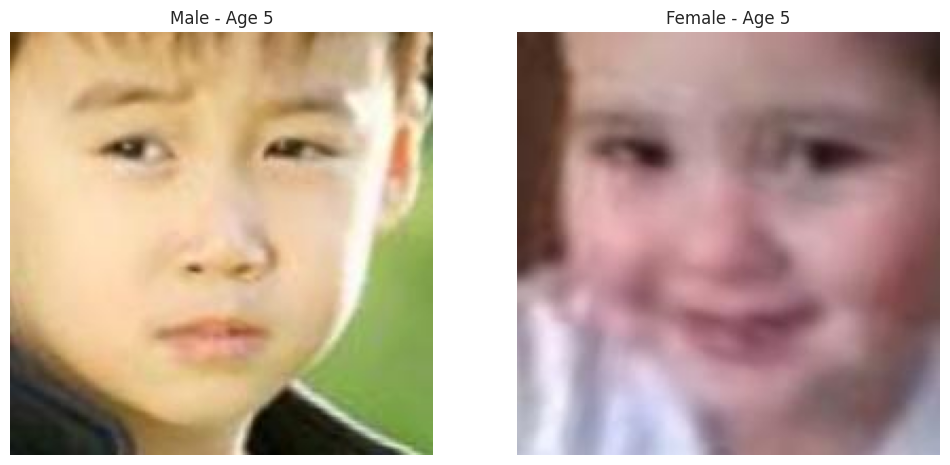

In [78]:
male_age_5 = data_map["5_0"][0]
m5_image = mpimg.imread(male_age_5)

female_age_5 = data_map["5_1"][0]
f5_image = mpimg.imread(female_age_5)

fig, axes = plt.subplots(1,2, figsize=(12,6))
axes[0].imshow(m5_image)
axes[0].axis('off') 
axes[0].set_title("Male - Age 5")

axes[1].imshow(f5_image)
axes[1].axis('off')
axes[1].set_title("Female - Age 5")
plt.show()

# Data splitting

Creating train, validation and test splits from 23708 samples. while keeping age and gender ratio in mind.

Final data size:

* Training: 17,701 samples 
* Validation: 3,467 samples
* Testing: 2,540 samples

In [59]:
training_samples = []
validation_samples = []
testing_samples = []

train_ratio = 0.75
val_ratio = 0.15

for label, image_list in data_map.items():
    random.seed(42)
    random.shuffle(image_list)

    n = len(image_list)

    train_end = int(n*train_ratio)
    val_end = int(n*val_ratio) + train_end

    training_samples.extend(image_list[:train_end])
    validation_samples.extend(image_list[train_end:val_end])
    testing_samples.extend(image_list[val_end:])

print(f'Total Training samples: {len(training_samples)}')
print(f'Total Validation samples: {len(validation_samples)}')
print(f'Total Testing samples: {len(testing_samples)}')

Total Training samples: 17701
Total Validation samples: 3467
Total Testing samples: 2540
